In [2]:
import os
os.chdir('./../')

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
acevedo_to_rest = {
    'nirschl-lab/kather_et_al_2018': {4:3 #lymphocyte: lymphocytes
                                      },
    'nirschl-lab/kather_et_al_2016': {4:3 #lymphocyte: lympho
                                      },
    'nirschl-lab/jung_et_al_2022': {0:0, 1:1, 4:2, 5:3, 6:4}
}

In [8]:
csv_path = 'csv/acevedo_spectral_norm'
kather_2016 = pd.read_csv(os.path.join(csv_path, 'sngp_acevedo_kather.csv'))

In [14]:
indist_prob = kather_2016[kather_2016['target']==3]['prediction_prob_score']
outdist_prob = kather_2016[kather_2016['target']!=3]['prediction_prob_score']

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def single_model_probability_histogram(
    probs_indsit: np.ndarray,
    probs_outdist: np.ndarray,
    bins=25,
    alpha=0.6,
    labels=("In-distribution", "Out-of-distribution")
):
    """
    Plots two probability histograms on the same figure for comparison,
    with y-axis percentages computed over the combined total number of samples.
    """

    fig, ax = plt.subplots(figsize=(6, 5))

    # Combine for total normalization
    total_len = len(probs_indsit) + len(probs_outdist)

    # Plot in-distribution histogram
    ax.hist(
        probs_indsit,
        bins=bins,
        alpha=alpha,
        weights=np.ones_like(probs_indsit) / total_len,  # combined normalization
        edgecolor='black',
        label=labels[0],
        color='tab:blue'
    )

    # Plot out-of-distribution histogram
    ax.hist(
        probs_outdist,
        bins=bins,
        alpha=alpha,
        weights=np.ones_like(probs_outdist) / total_len,  # combined normalization
        edgecolor='black',
        label=labels[1],
        color='tab:orange'
    )

    # Format y-axis as percentage of total
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y * 100:.0f}%"))

    # Axis settings
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probability")
    ax.set_ylabel("Percentage (of total samples)")
    ax.set_title("Output Probability Distributions (Combined Percentage)")

    # Add legend
    ax.legend()

    return fig


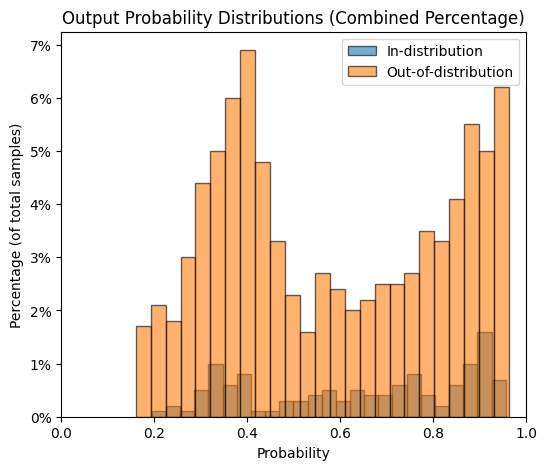

In [27]:
fig = single_model_probability_histogram(probs_indsit = np.array(indist_prob), probs_outdist = np.array(outdist_prob), bins=25, alpha=0.6)


In [4]:
csv_path = 'csv/acevedo_spectral_norm'
os.listdir(csv_path)

['sngp_acevedo_nirschl.csv',
 'sngp_acevedo_acevedo.csv',
 'sngp_acevedo_kather.csv',
 'sngp_acevedo_jung.csv',
 'sngp_acevedo_tang.csv',
 'sngp_acevedo_wong.csv']

In [28]:
jung = pd.read_csv(os.path.join(csv_path, 'sngp_acevedo_jung.csv'))

In [31]:
jung_class_to_ix = {'basophil': 0, 'eosinophil': 1, 'lymphocyte': 2, 'monocyte': 3, 'neutrophil': 4}
jung_ix_to_class = {value: key for key, value in jung_class_to_ix.items()}

In [30]:
jung.head()

,image_id,target,prediction,prediction_prob_score,true_bin_label,class_probs,fold
0,9434e92e-6552-4076-b425-85f6fd5b8496,2,2,0.217356,1,"[0.03497585281729698, 0.12177460640668869, 0.2...",test
1,050363bf-bd8d-4147-8fb2-b96b8e37946a,0,3,0.800854,0,"[0.016403207555413246, 0.04579022154211998, 0....",test
2,ee7ff35c-35cb-41a3-a1ce-fc15b214b788,1,1,0.955511,1,"[0.0033207025844603777, 0.9555109143257141, 0....",test
3,c68d5f6a-2342-4e3d-9ed8-9aadc3a90fa8,2,3,0.463079,0,"[0.03159186244010925, 0.056932248175144196, 0....",test
4,b4eec4a4-6521-4cf2-8f25-6ccf6d2a7f95,2,1,0.495074,0,"[0.028512462973594666, 0.49507394433021545, 0....",test


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def classwise_probability_histogram(
    df: pd.DataFrame,
    ix_to_classes: dict,
    model = 'model',
    testdata = 'testdata',
    reference_column = 'target',
    bins=25,
    alpha=0.6,
    figsize=(8, 6)
):
    """
    Plots histograms of prediction probabilities for each class.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ["target", "prediction_prob_score"].
    ix_to_classes : dict
        Mapping from numeric class index to class name.
    bins : int
        Number of bins for histograms.
    alpha : float
        Transparency for histogram bars.
    figsize : tuple
        Figure size.
    """

    fig, ax = plt.subplots(figsize=figsize)

    # Ensure inputs are valid
    if reference_column not in df.columns or "prediction_prob_score" not in df.columns:
        raise ValueError(f"DataFrame must contain {reference_column} and 'prediction_prob_score' columns.")

    # Combine for normalization (total % across all classes)
    total_len = len(df)

    # Plot histogram per class
    for cls_idx, cls_name in ix_to_classes.items():
        class_probs = df.loc[df[reference_column] == cls_idx, "prediction_prob_score"].values
        if len(class_probs) == 0:
            continue  # skip empty classes
        ax.hist(
            class_probs,
            bins=bins,
            alpha=alpha,
            weights=np.ones_like(class_probs) / total_len,  # normalize to total
            edgecolor='black',
            label=cls_name
        )

    # Formatting
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y * 100:.0f}%"))
    ax.set_xlim(0, 1)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Percentage (of total samples)")
    ax.set_title(f"Class-wise Prediction Probability - Model: {model} test data: {testdata}")
    ax.legend(title="True Class", fontsize=9)

    plt.tight_layout()
    # return fig


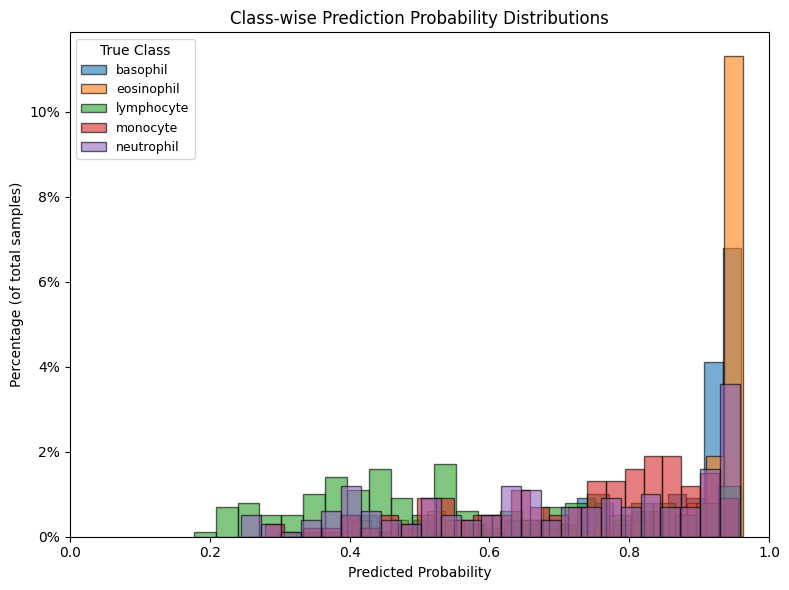

In [37]:
classwise_probability_histogram(jung, jung_ix_to_class)

In [38]:
csv_path = 'csv/tang_spectral_norn_newloss'
os.listdir(csv_path)

['sngp_tang_kather2016.csv',
 'sngp_tang_wong.csv',
 'sngp_tang_kather2018.csv',
 'sngp_tang_nirschl.csv']

In [41]:
sngp_tang_kather2016 = pd.read_csv(os.path.join(csv_path, 'sngp_tang_kather2016.csv'))
sngp_tang_kather2018 = pd.read_csv(os.path.join(csv_path, 'sngp_tang_kather2018.csv'))
sngp_tang_wong = pd.read_csv(os.path.join(csv_path, 'sngp_tang_wong.csv'))
sngp_tang_nirschl = pd.read_csv(os.path.join(csv_path, 'sngp_tang_nirschl.csv'))


In [46]:
tang_et_al_2019 = {'caa': 0, 'cored': 1, 'diffuse': 2, 'negative': 3}
tang_ix_to_classes = {value:key for key, value in tang_et_al_2019.items()}
reference_column = 'prediction'

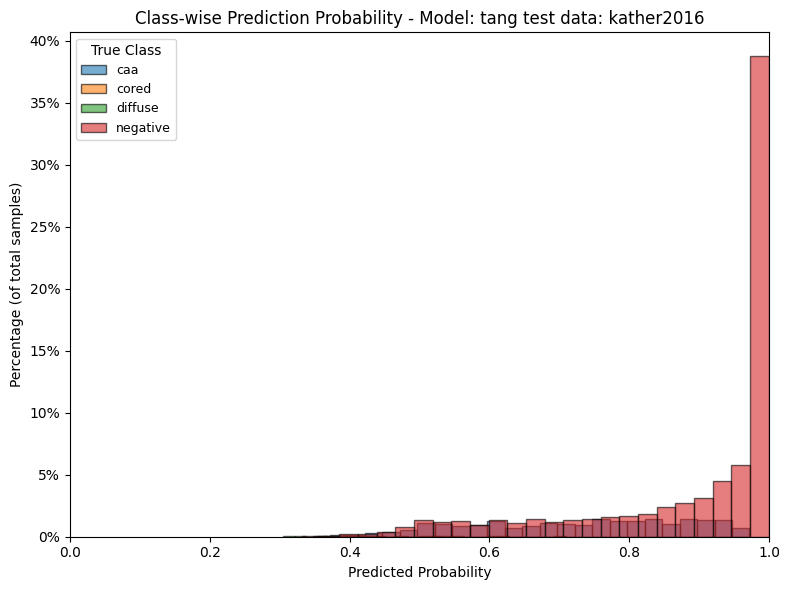

In [53]:
classwise_probability_histogram(df = sngp_tang_kather2016, ix_to_classes = tang_ix_to_classes, model = 'tang',
    testdata = 'kather2016',reference_column=reference_column)

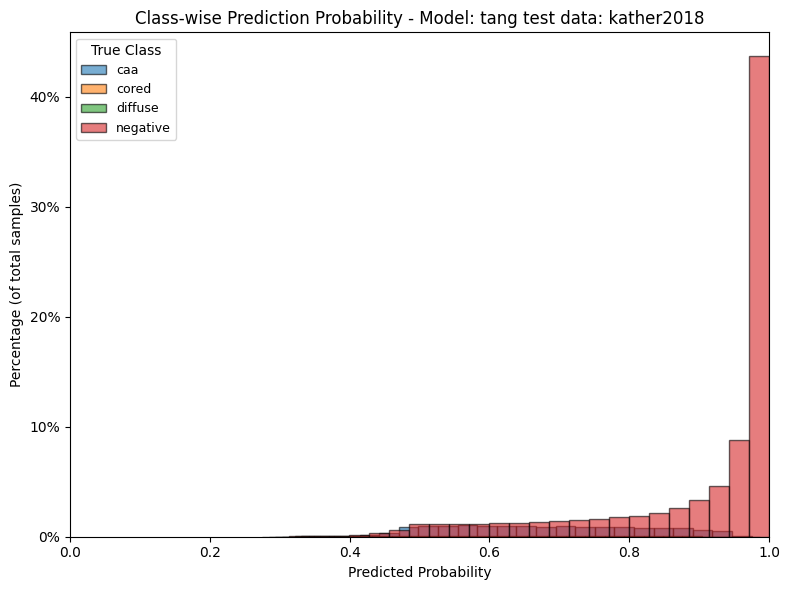

In [54]:
classwise_probability_histogram(df = sngp_tang_kather2018, ix_to_classes = tang_ix_to_classes, model = 'tang',
    testdata = 'kather2018',reference_column=reference_column)

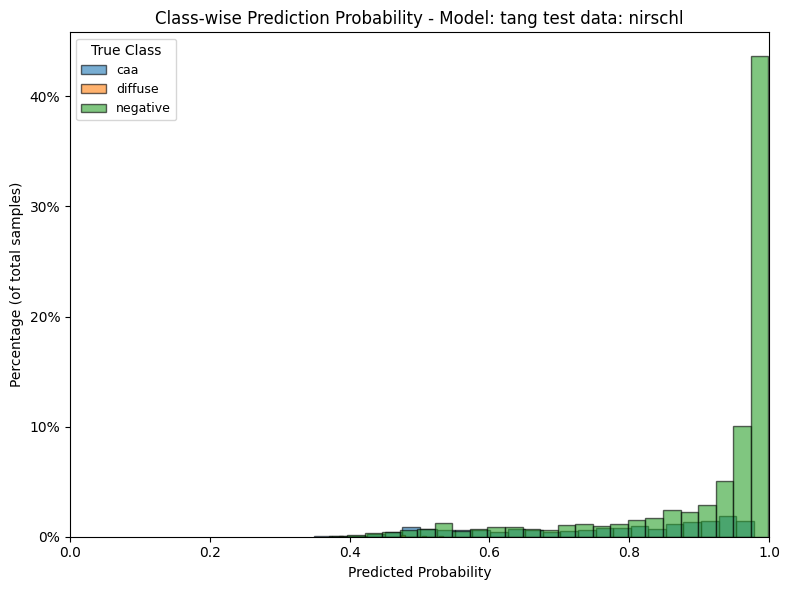

In [56]:
classwise_probability_histogram(df = sngp_tang_nirschl, ix_to_classes = tang_ix_to_classes, model = 'tang',
    testdata = 'nirschl',reference_column=reference_column)

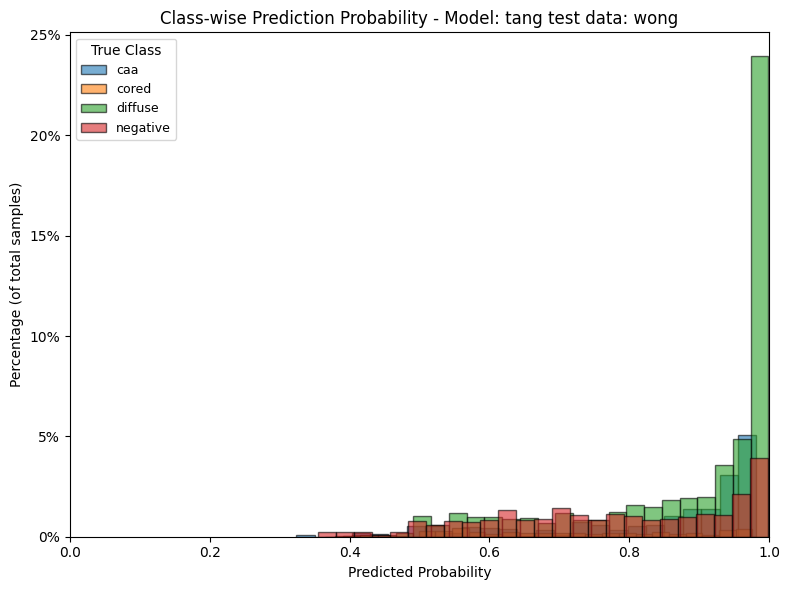

In [57]:
classwise_probability_histogram(df = sngp_tang_wong, ix_to_classes = tang_ix_to_classes, model = 'tang',
    testdata = 'wong',reference_column=reference_column)